In [74]:
import pandas as pd
import seaborn as sns #importing seaboran and matplot for visualization 
import matplotlib.pyplot as plt 
from sklearn.preprocessing import LabelEncoder #converting string values in numberical 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix

In [75]:
df=pd.read_csv("train.csv") #reading csv file using pandas library 

In [76]:
df.info() #show info about the dataset what type of data are there in dataset

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [77]:
df.describe() #statistical information about data set quantile percentile min max ets

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [78]:
df.head()#first five rows of dataset

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [79]:
df.shape  #count of rows and columns

(891, 12)

In [80]:
print(df.duplicated().sum()) #checking for duplicate rows

0


In [81]:

print(df.isnull().sum()) #looking for missing values or null valuyes


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [82]:
df.dtypes #info about datatypes what type of data is in which column

PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

In [83]:
#Data Story
# #The Titanic Disaster dataset contains 891 rows and 12 columns.
# Among these 12 features, 5 are categorical (string) variables, while the remaining 7 are numerical variables. 
# The dataset includes passenger information such as age, gender, ticket details, fare, and survival status. 
# Missing values are primarily found in the Cabin, Age, and Embarked columns, which will require preprocessing before analysis.
# This combination of categorical and numerical features makes the dataset well-suited for exploratory data analysis, visualization, and predictive machine learning tasks.

In [84]:
for col in df.columns:
    if df[col].dtype=='object' or df[col].dtype=='string':
        df[col]=df[col].fillna(df[col].mode()[0])
    else:
        df[col]=df[col].fillna(df[col].median())  #handeling missing values

In [85]:

print(df.isnull().sum()) #recheck for missing values nuow all missing values are filled with some values 


PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64


In [86]:
# ## Handling Missing Values
# Missing values were handled using the `fillna()` method instead of `dropna()` because the Titanic dataset is relatively small.
# Dropping rows with missing values would reduce the amount of available data and could affect the quality of the analysis.
# Therefore, missing numerical values were replaced with the median, while missing categorical values were replaced with the mode to preserve the dataset.

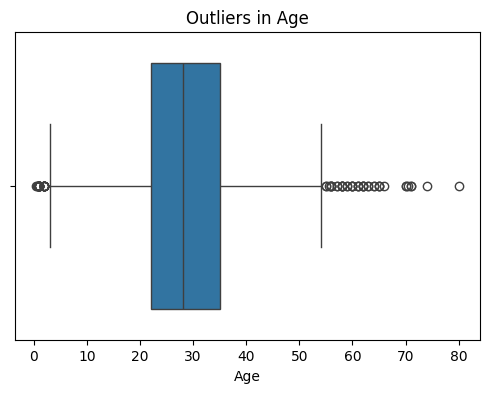

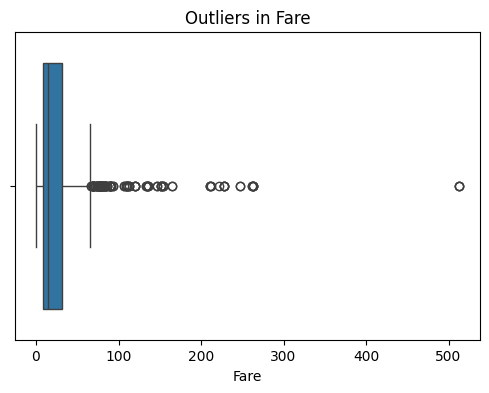

In [87]:
cols = ['Age', 'Fare']
#detecting outliers in age and fare however fare can be vary due to business class normal etc 
for x in cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[x])
    plt.title(f"Outliers in {x}")
    plt.show()

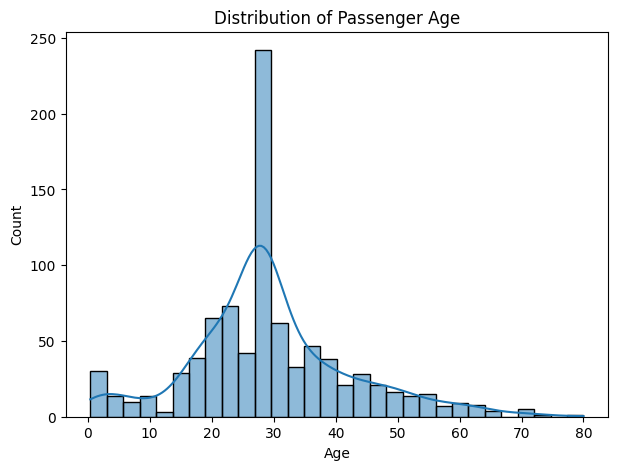

In [88]:
#histogram for detecting the age of people present on tatanic and this show most people lie's in between 20-28 year old and positive ly skewed
plt.figure(figsize=(7,5))

sns.histplot(df['Age'], bins=30, kde=True)

plt.title("Distribution of Passenger Age")
plt.xlabel("Age")
plt.ylabel("Count")

plt.show()

In [89]:
df.drop(['PassengerId','Name','Ticket','Cabin'],axis=1,inplace=True) #unnessary columns dropdown

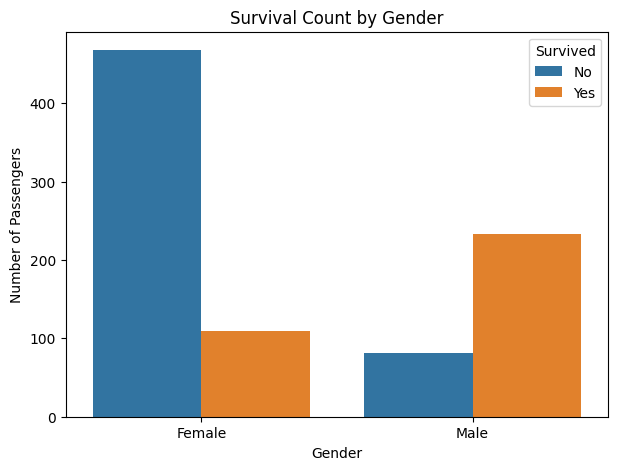

In [90]:
plt.figure(figsize=(7,5))

sns.countplot(x='Sex', hue='Survived', data=df)

plt.title("Survival Count by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")

plt.xticks([0,1],["Female","Male"])

plt.legend(title="Survived",labels=["No","Yes"])#bar graph telling about the surival from geners 

plt.show()

In [92]:
le = LabelEncoder()

df['Sex'] = le.fit_transform(df['Sex'])
df['Embarked'] = le.fit_transform(df['Embarked'])

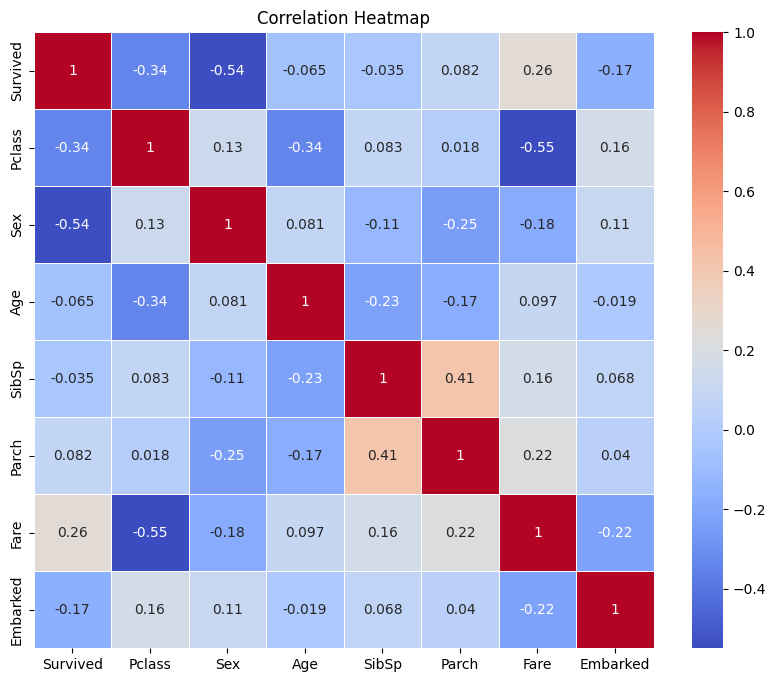

In [93]:
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(),
            annot=True,
            cmap='coolwarm',
            linewidths=0.5)

plt.title("Correlation Heatmap")

plt.show()

In [94]:
## feature that affects survival
# According to the correlation heatmap, the Sex column has the strongest influence on passenger survival.
# Female passengers had a much higher survival rate than male passengers.This observation is consistent with the historical evacuation policy of "women and children first" during the Titanic disaster.
# Passenger class (Pclass) also shows an effect on survival, as first-class passengers generally had a better chance of surviving due to easier access to lifeboats. 
#However, based on the correlation analysis and visualizations, Sex appears to be the most influential feature affecting survival.


In [95]:
X = df.drop("Survived", axis=1)

y = df["Survived"]

In [96]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42 )

In [97]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8100558659217877


In [98]:
cm = confusion_matrix(y_test, y_pred)

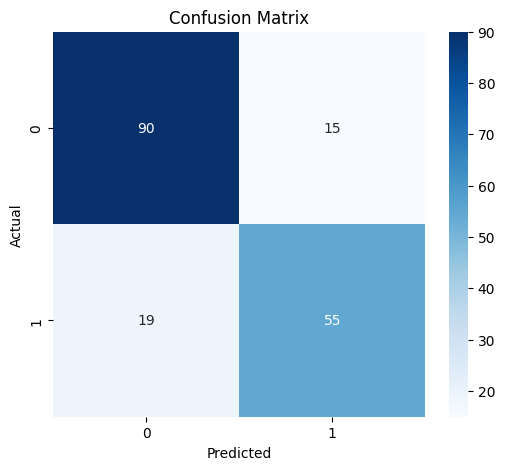

In [99]:
plt.figure(figsize=(6,5))

sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [100]:
# Confusion Matrix Interpretation

# The model correctly identified 90 passengers who did not survive.

# It incorrectly predicted that 15 passengers survived when they actually did not.

# It also missed 19 passengers who actually survived by predicting they did not survive.

# The model correctly identified 55 passengers who survived.

# Overall, the model achieved an accuracy of about 81%, which means it made the correct prediction for most passengers
#Since most of the values are on the main diagonal of the confusion matrix, it shows that the Logistic Regression model performed well,
#with only a few incorrect predictions.
